In [51]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.decomposition import PCA

In [40]:
df = pd.read_csv("data/chinese-tea-dataset.csv")

In [41]:
df

,id,name_en,name_zh,category,region,caffeine_level,body,oxidation_level,flavor_primary,description_brief,tier
0,alishan-oolong,Alishan High Mountain Oolong,阿里山乌龙,Oolong Tea,Alishan,moderate,medium,0.20,"floral,butter,cream",Lightly oxidized oolong from Taiwan's Alishan ...,1
1,anji-bai-cha,Anji Bai Cha (Anji White Tea),安吉白茶,Green Tea,Anji County,low,light,0.02,"umami,chestnut,bamboo","A unique green tea (not white, despite the nam...",1
2,bai-hao-yinzhen,Bai Hao Yin Zhen (Silver Needle),白毫银针,White Tea,Fuding,low,light,0.08,"melon,honey,hay","The highest grade of white tea, made exclusive...",1
3,bai-mudan,Bai Mudan (White Peony),白牡丹,White Tea,Fuding,low,light-medium,0.10,"floral,honey,hay","White tea featuring one bud and two leaves, of...",1
4,biluochun,Biluochun (Green Snail Spring),碧螺春,Green Tea,Dongting Mountain,moderate,light,0.02,"fruity,floral,fresh",Prized spring green tea from Dongting Mountain...,1
...,...,...,...,...,...,...,...,...,...,...,...
131,zhi-lan-xiang,Zhi Lan Xiang (Orchid Fragrance),芝兰香,Oolong Tea,Phoenix Mountain,moderate,medium,0.45,"orchid,floral,sweet",A classic dancong variety prized for its pure ...,2
132,zhu-ye-qing,Zhu Ye Qing (Bamboo Leaf Green),竹叶青,Green Tea,Mount Emei,moderate,light,0.02,"fresh,vegetal,sweet",Premium green tea from Mount Emei in Sichuan. ...,2
133,lotus-green-tea,Lotus Green Tea,莲花绿茶,Scented Tea,Zhejiang,low,light,0.03,"lotus,fresh,floral","Green tea scented with lotus flowers. Fresh, f...",3
134,magnolia-oolong,Magnolia Oolong,玉兰乌龙,Scented Tea,Fujian,moderate,medium,0.30,"magnolia,creamy,floral","Oolong scented with magnolia flowers. Creamy, ...",3


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136 entries, 0 to 135
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 136 non-null    object 
 1   name_en            136 non-null    object 
 2   name_zh            136 non-null    object 
 3   category           136 non-null    object 
 4   region             136 non-null    object 
 5   caffeine_level     136 non-null    object 
 6   body               136 non-null    object 
 7   oxidation_level    136 non-null    float64
 8   flavor_primary     136 non-null    object 
 9   description_brief  136 non-null    object 
 10  tier               136 non-null    int64  
dtypes: float64(1), int64(1), object(9)
memory usage: 11.8+ KB


In [43]:
category = df['category'].value_counts()

In [44]:
caffeine = df['caffeine_level'].value_counts()

In [45]:
body = df['body'].value_counts()

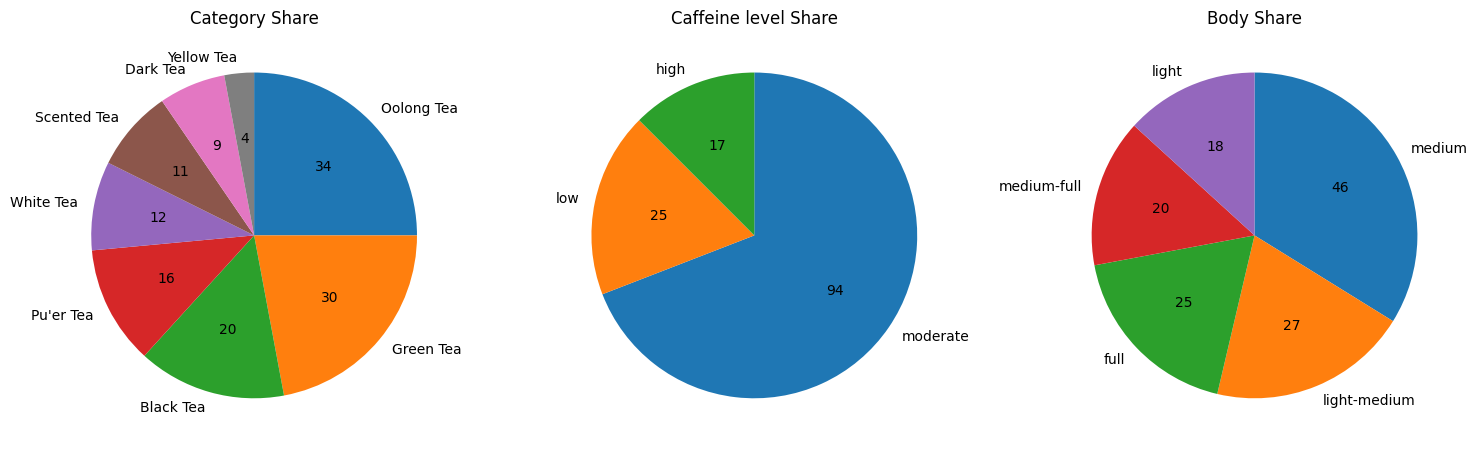

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

#Category
axes[0].pie(category, labels=category.index, autopct=lambda pct: f"{int(round(pct * category.sum() / 100))}", startangle=90, counterclock=False)
axes[0].set_title('Category Share')

#Caffeine level
axes[1].pie(caffeine, labels=caffeine.index, autopct=lambda pct: f"{int(round(pct * category.sum() / 100))}", startangle=90, counterclock=False)
axes[1].set_title('Caffeine level Share')

#Body
axes[2].pie(body, labels=body.index, autopct=lambda pct: f"{int(round(pct * category.sum() / 100))}", startangle=90, counterclock=False)
axes[2].set_title('Body Share')

plt.tight_layout()
plt.show()

- Encoding
- reduce dimation by using PCA

In [47]:
df = df.set_index('name_en')

In [48]:
df.columns

Index(['id', 'name_zh', 'category', 'region', 'caffeine_level', 'body',
       'oxidation_level', 'flavor_primary', 'description_brief', 'tier'],
      dtype='object')

In [49]:
drop = ['id', 'name_zh','region', 'oxidation_level', 'flavor_primary', 'description_brief', 'tier']
df_pca = df.drop(columns=drop)

In [50]:
df_pca

,category,caffeine_level,body
name_en,,,
Alishan High Mountain Oolong,Oolong Tea,moderate,medium
Anji Bai Cha (Anji White Tea),Green Tea,low,light
Bai Hao Yin Zhen (Silver Needle),White Tea,low,light
Bai Mudan (White Peony),White Tea,low,light-medium
Biluochun (Green Snail Spring),Green Tea,moderate,light
...,...,...,...
Zhi Lan Xiang (Orchid Fragrance),Oolong Tea,moderate,medium
Zhu Ye Qing (Bamboo Leaf Green),Green Tea,moderate,light
Lotus Green Tea,Scented Tea,low,light


### Ordinal Encoder

In [53]:
caffeine_cat = ["low", "moderate", "high"]
body_cat = ["light", "light-medium", "medium", "medium-full", "full"]

In [ ]:
ordinal_encoder = OrdinalEncoder(categories=[caffeine_cat,body_cat])
ordinal_encoder.fit(df_pca[["caffeine_level", "body"]])

OrdinalEncoder(categories=[['low', 'moderate', 'high'],
                           ['light', 'light-medium', 'medium', 'medium-full',
                            'full']])

In [66]:
df_pca[["caffeine_level", "body"]] = ordinal_encoder.transform(df_pca[["caffeine_level", "body"]])
df_pca

,category,caffeine_level,body
name_en,,,
Alishan High Mountain Oolong,Oolong Tea,1.0,2.0
Anji Bai Cha (Anji White Tea),Green Tea,0.0,0.0
Bai Hao Yin Zhen (Silver Needle),White Tea,0.0,0.0
Bai Mudan (White Peony),White Tea,0.0,1.0
Biluochun (Green Snail Spring),Green Tea,1.0,0.0
...,...,...,...
Zhi Lan Xiang (Orchid Fragrance),Oolong Tea,1.0,2.0
Zhu Ye Qing (Bamboo Leaf Green),Green Tea,1.0,0.0
Lotus Green Tea,Scented Tea,0.0,0.0


### OneHot Encoder

In [68]:
# Check unique values for category
print(f"The unique values for 'Alley' are {df_pca.category.unique()}")

The unique values for 'Alley' are ['Oolong Tea' 'Green Tea' 'White Tea' "Pu'er Tea" 'Black Tea'
 'Scented Tea' 'Yellow Tea' 'Dark Tea']


In [70]:
ohe = OneHotEncoder(sparse_output=False)
ohe.fit(df_pca[["category"]])

OneHotEncoder(sparse_output=False)

In [72]:
df_pca

,category,caffeine_level,body
name_en,,,
Alishan High Mountain Oolong,Oolong Tea,1.0,2.0
Anji Bai Cha (Anji White Tea),Green Tea,0.0,0.0
Bai Hao Yin Zhen (Silver Needle),White Tea,0.0,0.0
Bai Mudan (White Peony),White Tea,0.0,1.0
Biluochun (Green Snail Spring),Green Tea,1.0,0.0
...,...,...,...
Zhi Lan Xiang (Orchid Fragrance),Oolong Tea,1.0,2.0
Zhu Ye Qing (Bamboo Leaf Green),Green Tea,1.0,0.0
Lotus Green Tea,Scented Tea,0.0,0.0


In [74]:
df_pca[ohe.get_feature_names_out()] = ohe.transform(df_pca[["category"]])
df_pca = df_pca.drop(columns=["category"])

df_pca

,caffeine_level,body,category_Black Tea,category_Dark Tea,category_Green Tea,category_Oolong Tea,category_Pu'er Tea,category_Scented Tea,category_White Tea,category_Yellow Tea
name_en,,,,,,,,,,
Alishan High Mountain Oolong,1.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
Anji Bai Cha (Anji White Tea),0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
Bai Hao Yin Zhen (Silver Needle),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
Bai Mudan (White Peony),0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
Biluochun (Green Snail Spring),1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
Zhi Lan Xiang (Orchid Fragrance),1.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
Zhu Ye Qing (Bamboo Leaf Green),1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
Lotus Green Tea,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
